# Sepsis Cases: pipeline T-LEAF modulare

Questo notebook usa la nuova interfaccia di `src.Sepsis_Case` e percorre
l'intero esperimento: caricamento XES, analisi, split per caso, DFA,
dataset dei prefissi, GRU/LSTM, baseline, loss logica, valutazione e
confronto finale.

## Corrispondenza con la repository originale

| Fase T-LEAF originale | Adattamento Sepsis |
|---|---|
| Preprocessing del task target | Parsing XES e prefissi delle tracce |
| Formula/ricetta trasformata in DFA | DFA empirico appreso solo dal training set |
| Modello target LSTM/TCN baseline | GRU e LSTM baseline |
| Checker loss | Massa di probabilita assegnata a transizioni vietate |
| Embedder loss appresa | Non riprodotta: mancano formule e corpus edge/meta-embedder |
| Valutazione e grafi DFA | Accuratezza/F1/top-k/conformance e grafici |

Il notebook preserva quindi la pipeline sperimentale del task target e
la variante checker-style. Non presenta la penalita DFA come equivalente
alla meta-embedder loss originale.

In [2]:
%matplotlib inline

import json
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Image, display

ROOT = Path.cwd()
while not (ROOT / "src" / "Sepsis_Case").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.Sepsis_Case.config import ExperimentConfig
from src.Sepsis_Case.data import (
    ActivityVocabulary,
    extract_traces,
    make_data_loader,
    make_prefix_examples,
    read_xes,
    split_traces,
)
from src.Sepsis_Case.learning import (
    NextActivityGRU,
    NextActivityLSTM,
    NextActivityTransformer,
    build_allowed_mask,
    evaluate_model,
    load_checkpoint,
    train_model,
)
from src.Sepsis_Case.learning.training import resolve_device
from src.Sepsis_Case.pipeline import create_next_run
from src.Sepsis_Case.pipeline.analysis import (
    build_analysis_tables,
    summarise,
)
from src.Sepsis_Case.process import ProcessDFA
from src.Sepsis_Case.visualization import (
    plot_activity_frequency,
    plot_automaton,
    plot_case_durations,
    plot_learning_curves,
    plot_model_comparison,
    plot_variants,
)

## 1. Configurazione riproducibile

`QUICK_RUN=True` percorre tutte le fasi su un sottoinsieme e con poche
epoche. Impostarlo a `False` usa l'intero log e la configurazione standard.

In [3]:
QUICK_RUN = False
DATA_PATH = ROOT / "datasets/Sepsis_Case/Sepsis_Cases_Event_Log.xes"
RUN_PATHS = create_next_run(ROOT / "runs", "Sepsis_Case")
OUTPUT_DIR = RUN_PATHS.root
MODEL_DIR = RUN_PATHS.models
print("Run directory:", OUTPUT_DIR)

config = ExperimentConfig(seed=42)
config = replace(
    config,
    training=replace(
        config.training,
        epochs=50,
        early_stopping_patience=5,
        early_stopping_min_delta=1e-4,
        early_stopping_min_epochs=10,
        device="auto",
    ),
)
max_cases = None
device = resolve_device(config.training.device)
print("Dataset:", DATA_PATH)
print("Device:", device)
print("Configurazione:", json.dumps(config.to_dict(), indent=2))

Run directory: /mnt/c/Users/Matteo/PycharmProjects/T-LEAF/runs/Sepsis_Case_run_2
Dataset: /mnt/c/Users/Matteo/PycharmProjects/T-LEAF/datasets/Sepsis_Case/Sepsis_Cases_Event_Log.xes
Device: cuda
Configurazione: {
  "seed": 42,
  "data": {
    "validation_fraction": 0.15,
    "test_fraction": 0.15,
    "batch_size": 128,
    "num_workers": 0
  },
  "model": {
    "embedding_dim": 32,
    "hidden_dim": 64,
    "dropout": 0.2,
    "transformer_heads": 4,
    "transformer_layers": 2,
    "transformer_feedforward_dim": 128,
    "transformer_max_length": 512
  },
  "training": {
    "epochs": 50,
    "learning_rate": 0.002,
    "weight_decay": 1e-05,
    "task_loss_weight": 1.0,
    "logic_weight": 0.5,
    "gradient_clip": 1.0,
    "top_k": 3,
    "early_stopping_patience": 5,
    "early_stopping_min_delta": 0.0001,
    "early_stopping_min_epochs": 10,
    "device": "auto"
  }
}


## 2. Caricamento del log XES

In [4]:
events = read_xes(DATA_PATH, max_cases=max_cases)
print(f"{events['case_id'].nunique()} casi, {len(events)} eventi")
display(events.head())

1050 casi, 15214 eventi


,case_id,event_index,activity,timestamp,org_group,lifecycle,InfectionSuspected,DiagnosticBlood,DisfuncOrg,SIRSCritTachypnea,...,SIRSCritLeucos,Oligurie,DiagnosticLacticAcid,Diagnose,Hypoxie,DiagnosticUrinarySediment,DiagnosticECG,Leucocytes,CRP,LacticAcid
0,A,0,ER Registration,2014-10-22 09:15:41+00:00,A,complete,True,True,True,True,...,False,False,True,A,False,True,True,NaN,NaN,NaN
1,A,1,Leucocytes,2014-10-22 09:27:00+00:00,B,complete,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.6,NaN,NaN
2,A,2,CRP,2014-10-22 09:27:00+00:00,B,complete,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,NaN
3,A,3,LacticAcid,2014-10-22 09:27:00+00:00,B,complete,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.2
4,A,4,ER Triage,2014-10-22 09:33:37+00:00,C,complete,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Analisi esplorativa di eventi, casi, varianti e attributi

In [5]:
tables = build_analysis_tables(events)
dataset_summary = summarise(tables, DATA_PATH)
display(pd.Series(dataset_summary, name="valore").to_frame())
display(tables.activities.head(16))
display(tables.cases.head())
display(tables.transitions.head(20))
display(tables.attributes)

,valore
input,/mnt/c/Users/Matteo/PycharmProjects/T-LEAF/dat...
cases,1050
events,15214
activities,16
variants,846
groups,26
events_per_case,"{'mean': 14.48952380952381, 'median': 13.0, 'm..."
duration_hours,"{'mean': 683.2594277777778, 'median': 128.2412..."
outcomes,"{'return_er_cases': 294, 'admission_ic_cases':..."
most_common_activity,Leucocytes


,activity,count
0,Leucocytes,3383
1,CRP,3262
2,LacticAcid,1466
3,Admission NC,1182
4,ER Triage,1053
5,ER Registration,1050
6,ER Sepsis Triage,1049
7,IV Antibiotics,823
8,IV Liquid,753
9,Release A,671


,case_id,event_count,unique_activities,start_time,end_time,start_activity,end_activity,duration_hours,variant,has_return_er,has_admission_ic,has_release
0,A,22,10,2014-10-22 09:15:41+00:00,2014-11-02 14:15:00+00:00,ER Registration,Release A,268.988611,ER Registration > Leucocytes > CRP > LacticAci...,False,False,True
1,AA,8,8,2014-12-03 08:06:44+00:00,2014-12-03 13:28:01+00:00,ER Registration,IV Antibiotics,5.354722,ER Registration > ER Triage > ER Sepsis Triage...,False,False,False
2,AAA,11,11,2014-11-19 02:16:21+00:00,2014-11-28 15:15:17+00:00,ER Registration,Return ER,228.982222,ER Registration > ER Triage > ER Sepsis Triage...,True,False,True
3,AB,8,8,2014-02-16 08:55:43+00:00,2014-02-16 12:52:06+00:00,ER Registration,IV Antibiotics,3.939722,ER Registration > ER Triage > ER Sepsis Triage...,False,False,False
4,ABA,17,10,2014-10-12 09:22:24+00:00,2014-10-18 14:15:00+00:00,ER Registration,Release A,148.876667,ER Registration > ER Triage > ER Sepsis Triage...,False,False,True


,activity,next_activity,count
0,Leucocytes,CRP,1778
1,CRP,Leucocytes,1445
2,ER Registration,ER Triage,971
3,ER Triage,ER Sepsis Triage,905
4,CRP,LacticAcid,629
5,LacticAcid,Leucocytes,565
6,IV Liquid,IV Antibiotics,501
7,IV Antibiotics,Admission NC,489
8,Leucocytes,Leucocytes,458
9,Leucocytes,LacticAcid,435


,attribute,observations,missing_rate,cases_with_value,case_coverage,unique_values,type,mean_or_true_rate,min,max
0,Age,1050,0.930985,1050,1.000000,15,numeric,70.080952,20.0,90.0
1,CRP,3123,0.794729,947,0.901905,371,numeric,113.745757,5.0,573.0
2,Diagnose,797,0.947614,797,0.759048,146,categorical,NaN,NaN,NaN
3,DiagnosticArtAstrup,1050,0.930985,1050,1.000000,2,boolean,0.282857,NaN,NaN
4,DiagnosticBlood,1050,0.930985,1050,1.000000,2,boolean,0.783810,NaN,NaN
5,DiagnosticECG,1050,0.930985,1050,1.000000,2,boolean,0.728571,NaN,NaN
6,DiagnosticIC,1050,0.930985,1050,1.000000,2,boolean,0.807619,NaN,NaN
7,DiagnosticLacticAcid,1050,0.930985,1050,1.000000,2,boolean,0.765714,NaN,NaN
8,DiagnosticLiquor,1050,0.930985,1050,1.000000,2,boolean,0.004762,NaN,NaN
9,DiagnosticOther,1050,0.930985,1050,1.000000,2,boolean,0.009524,NaN,NaN


Attivita


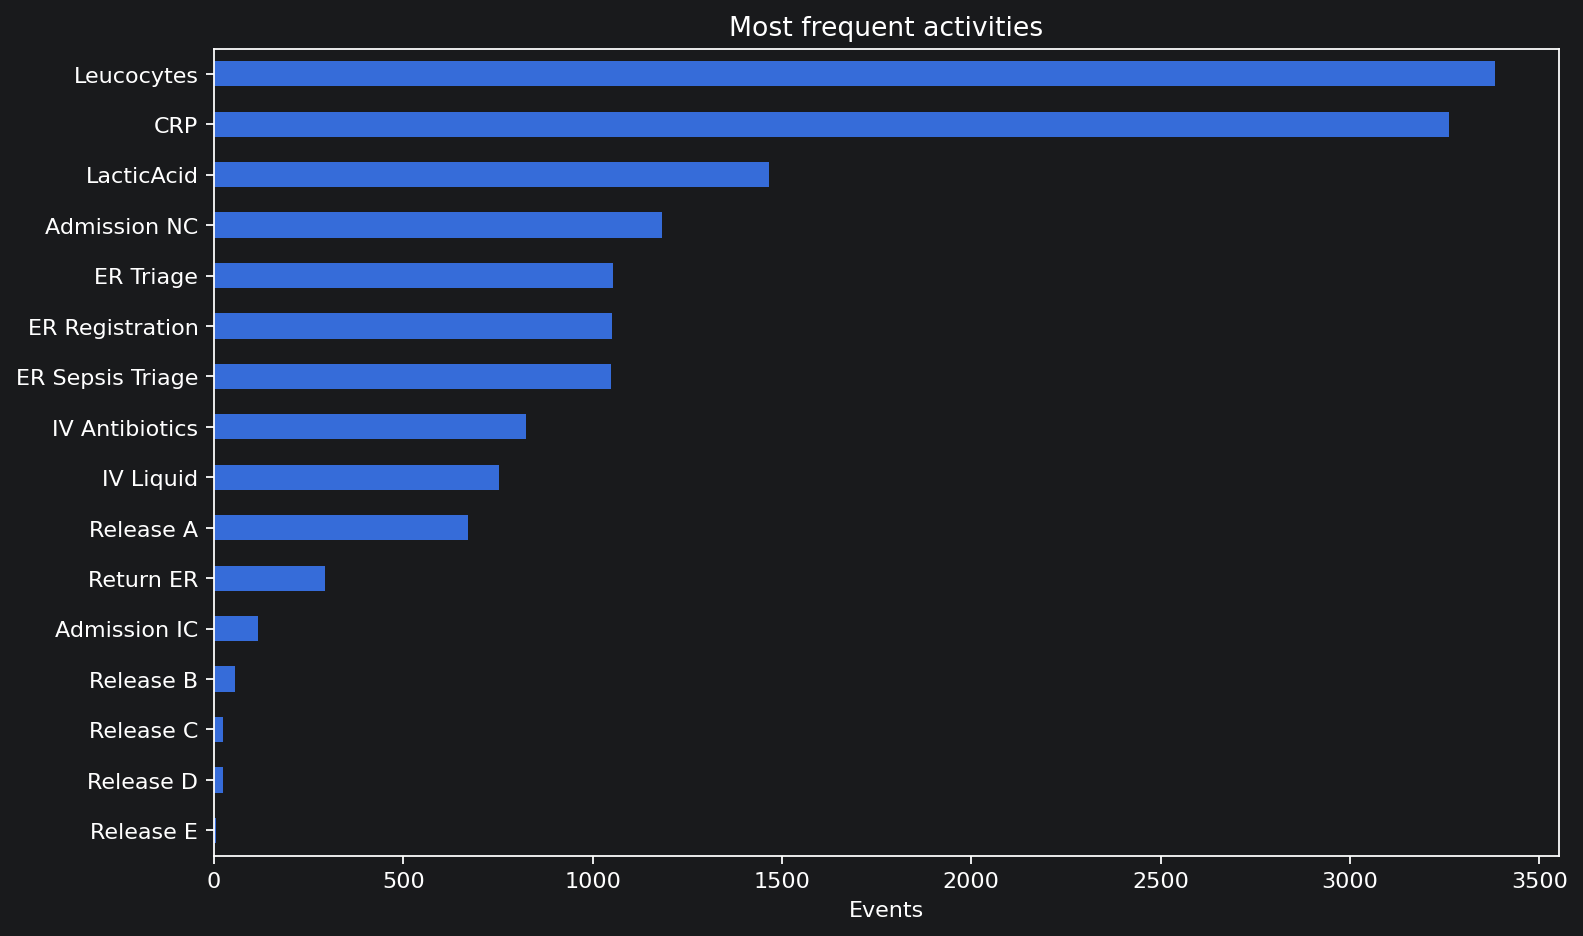

Durate


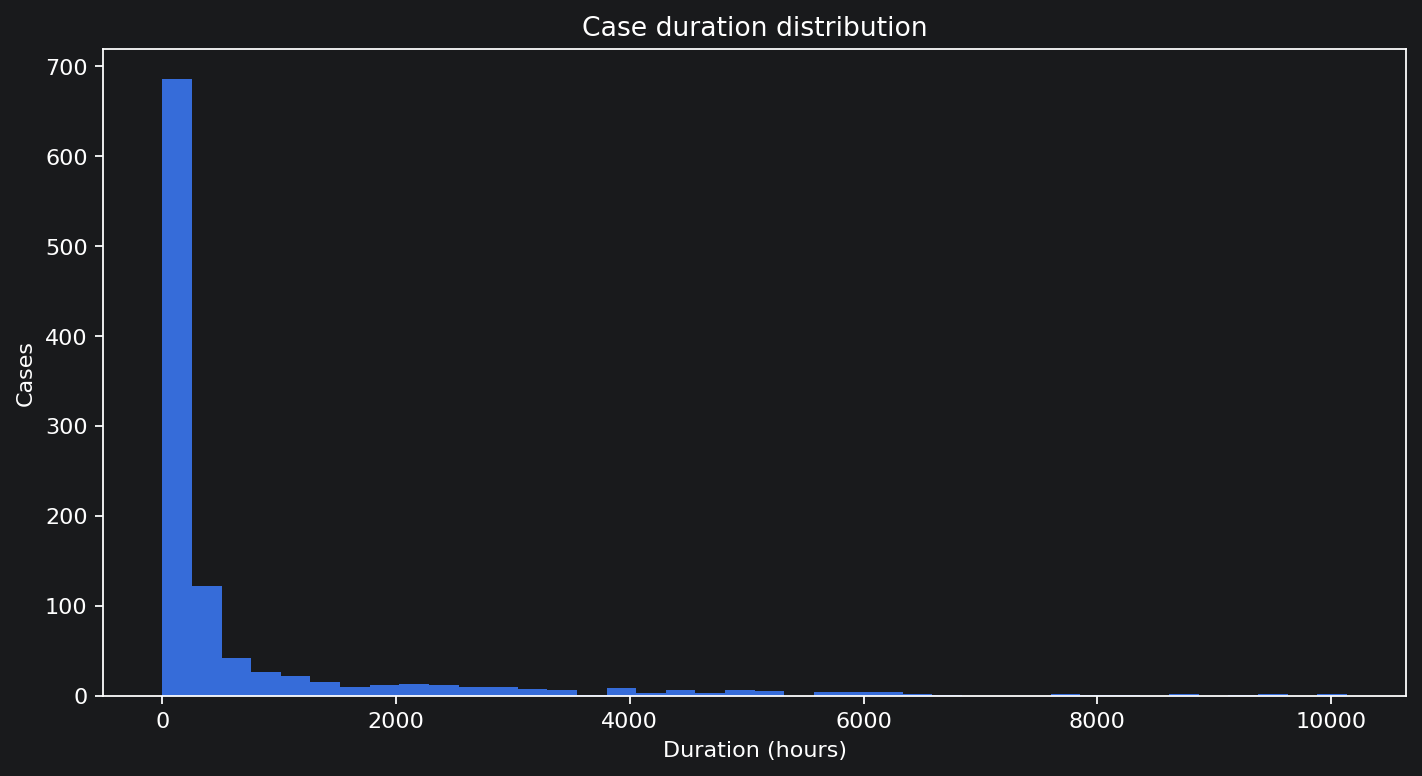

Varianti


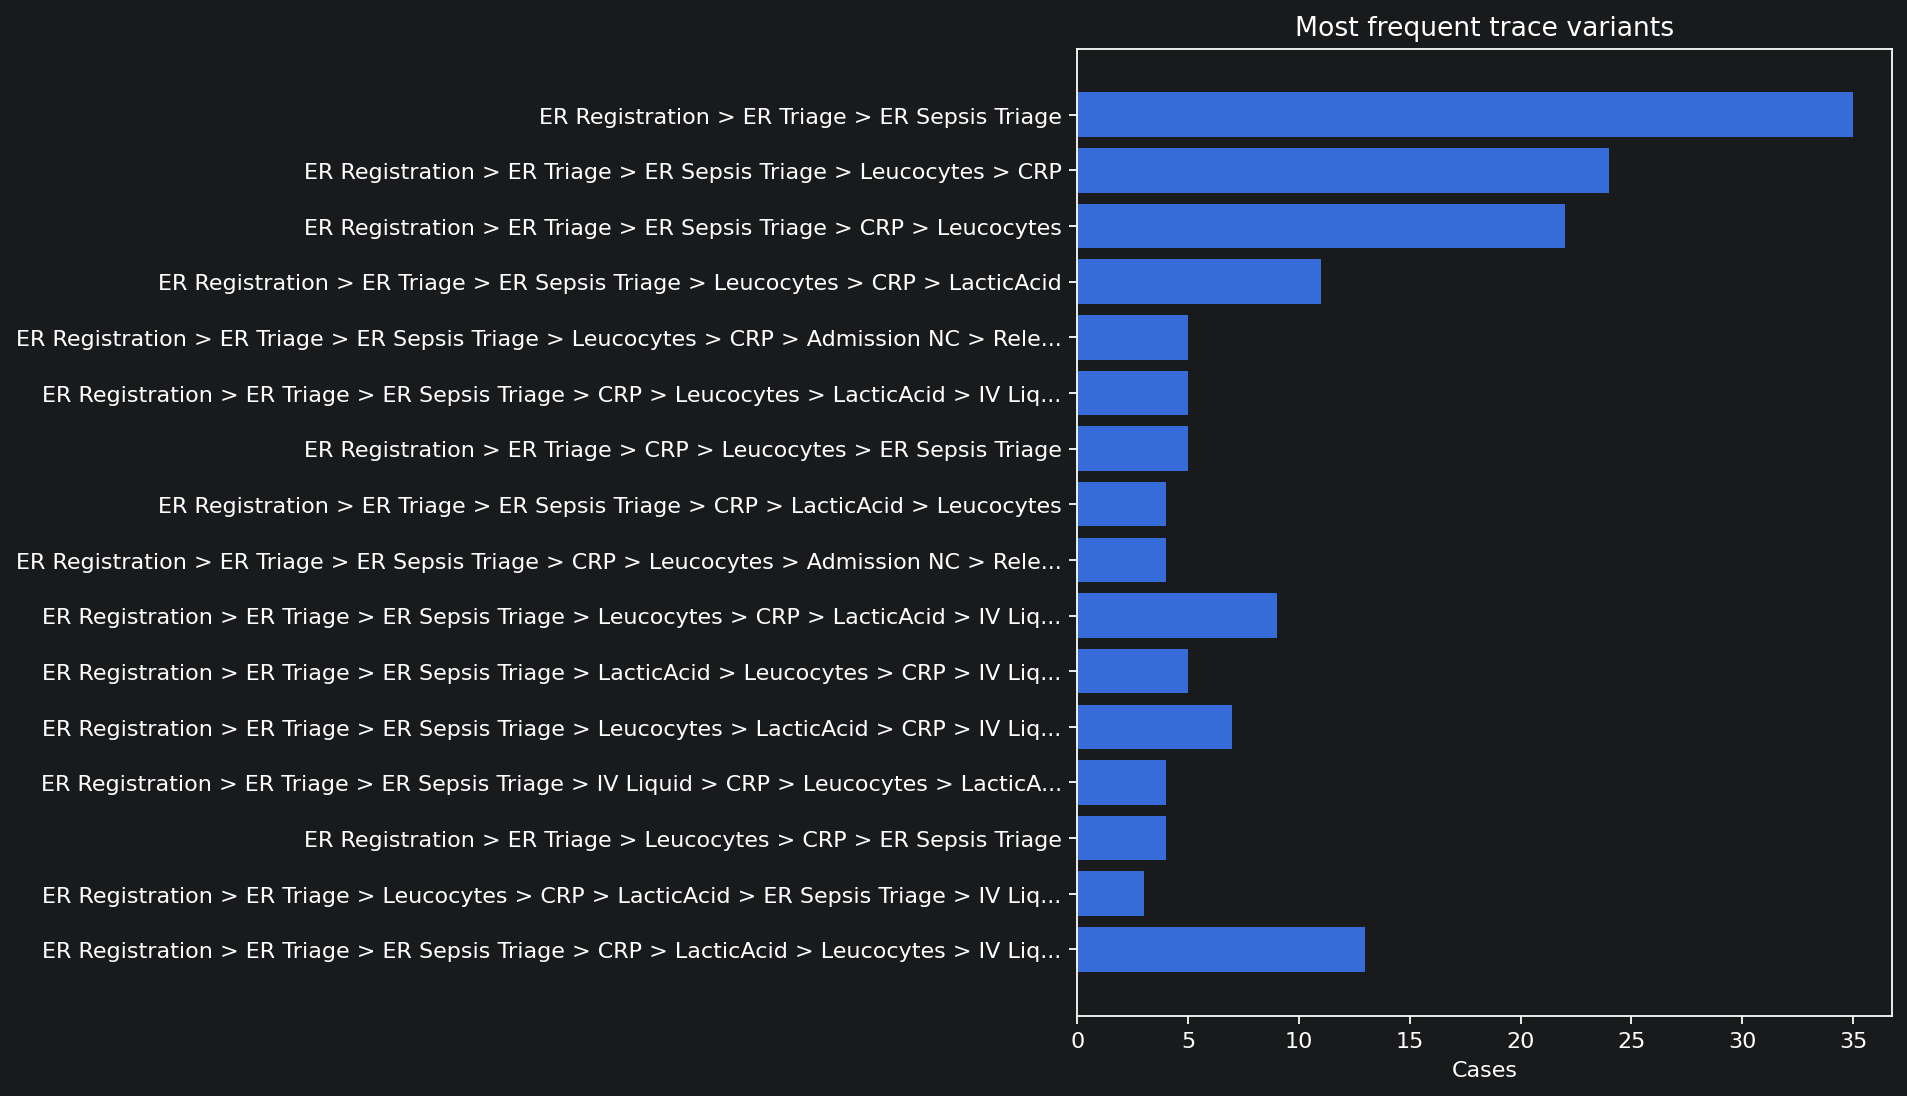

In [6]:
eda_paths = {
    "Attivita": OUTPUT_DIR / "activity_frequency.png",
    "Durate": OUTPUT_DIR / "case_duration_distribution.png",
    "Varianti": OUTPUT_DIR / "top_variants.png",
}
plot_activity_frequency(events, eda_paths["Attivita"])
plot_case_durations(tables.cases, eda_paths["Durate"])
plot_variants(tables.variants, eda_paths["Varianti"])
for title, path in eda_paths.items():
    print(title)
    display(Image(filename=path))

## 4. Tracce e split train/validation/test

Lo split avviene per `case_id`. Questa scelta evita leakage tra prefissi
dello stesso paziente e replica la separazione train/eval del task target
della repository originale.

In [7]:
traces = extract_traces(events)
splits = split_traces(
    traces,
    validation_fraction=config.data.validation_fraction,
    test_fraction=config.data.test_fraction,
    seed=config.seed,
)
split_summary = pd.DataFrame(
    {
        "cases": [
            len(splits.train),
            len(splits.validation),
            len(splits.test),
        ],
        "events": [
            sum(map(len, splits.train.values())),
            sum(map(len, splits.validation.values())),
            sum(map(len, splits.test.values())),
        ],
    },
    index=["train", "validation", "test"],
)
display(split_summary)
assert set(splits.train).isdisjoint(splits.validation)
assert set(splits.train).isdisjoint(splits.test)
assert set(splits.validation).isdisjoint(splits.test)

,cases,events
train,735,10740
validation,157,2315
test,158,2159


## 5. DFA del processo

Il DFA e costruito esclusivamente dalle tracce di training. Gli archi
rappresentano relazioni directly-follows consentite e diventano il
checker differenziabile usato durante il training logic-aware.

,value
states,18.000000
transitions,128.000000
validation_transition_coverage,0.996976
test_transition_coverage,0.999074
accepted_validation_traces,151.000000


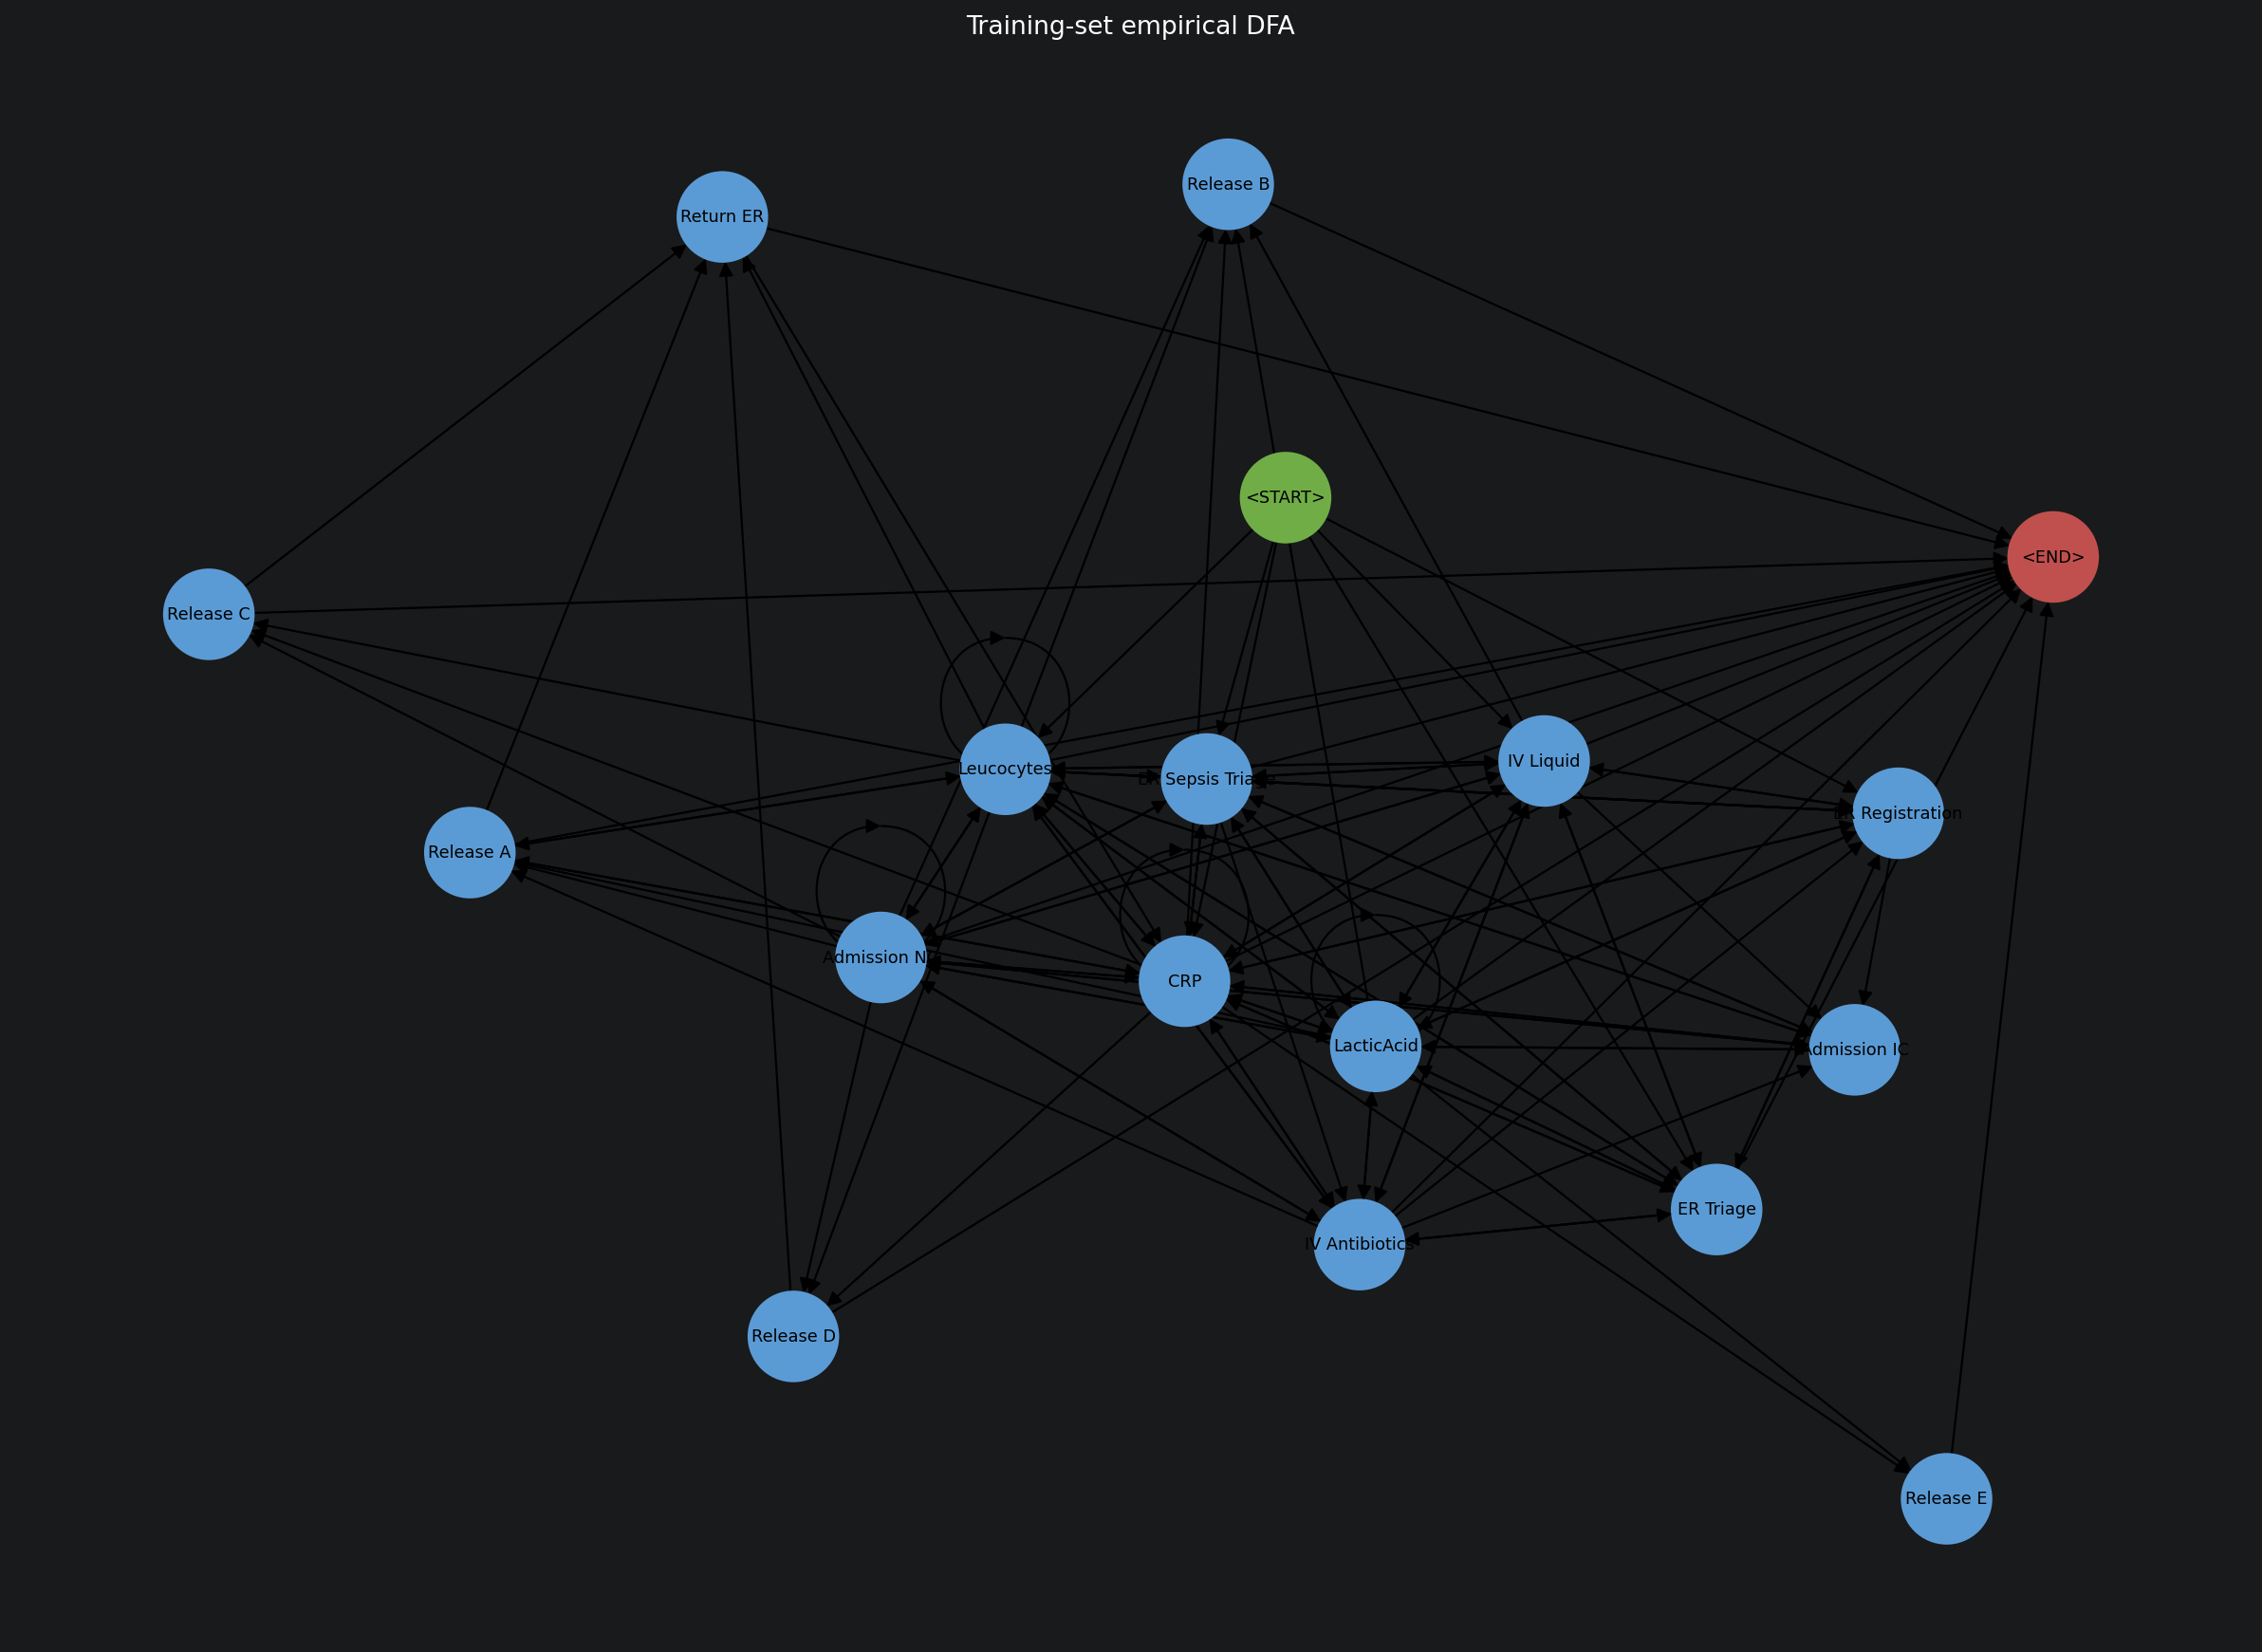

In [8]:
automaton = ProcessDFA.from_traces(splits.train.values())
dfa_path = OUTPUT_DIR / "dfa.png"
plot_automaton(automaton, dfa_path)

dfa_summary = pd.Series(
    {
        "states": len(automaton.states),
        "transitions": automaton.transition_count,
        "validation_transition_coverage": automaton.transition_coverage(
            splits.validation.values()
        ),
        "test_transition_coverage": automaton.transition_coverage(
            splits.test.values()
        ),
        "accepted_validation_traces": sum(
            automaton.accepts(trace) for trace in splits.validation.values()
        ),
    }
)
display(dfa_summary.to_frame("value"))
display(Image(filename=dfa_path))

## 6. Vocabolario e dataset supervisionato dei prefissi

In [9]:
vocabulary = ActivityVocabulary.from_traces(splits.train.values())
unseen = {
    action
    for partition in (splits.validation, splits.test)
    for trace in partition.values()
    for action in trace
    if action not in vocabulary.class_to_id
}
assert not unseen, f"Attivita non viste nel training: {sorted(unseen)}"

examples = {
    "train": make_prefix_examples(splits.train, vocabulary),
    "validation": make_prefix_examples(splits.validation, vocabulary),
    "test": make_prefix_examples(splits.test, vocabulary),
}
loaders = {
    name: make_data_loader(
        partition,
        vocabulary,
        batch_size=config.data.batch_size,
        shuffle=name == "train",
        num_workers=config.data.num_workers,
    )
    for name, partition in examples.items()
}
display(
    pd.Series(
        {name: len(partition) for name, partition in examples.items()},
        name="prefix_examples",
    ).to_frame()
)
print("Token input:", vocabulary.tokens)
print("Classi target:", vocabulary.activities)

,prefix_examples
train,10740
validation,2315
test,2159


Token input: ('<PAD>', '<START>', 'Admission IC', 'Admission NC', 'CRP', 'ER Registration', 'ER Sepsis Triage', 'ER Triage', 'IV Antibiotics', 'IV Liquid', 'LacticAcid', 'Leucocytes', 'Release A', 'Release B', 'Release C', 'Release D', 'Release E', 'Return ER')
Classi target: ('Admission IC', 'Admission NC', 'CRP', 'ER Registration', 'ER Sepsis Triage', 'ER Triage', 'IV Antibiotics', 'IV Liquid', 'LacticAcid', 'Leucocytes', 'Release A', 'Release B', 'Release C', 'Release D', 'Release E', 'Return ER')


## 7. Checker logico differenziabile

Per ogni ultimo token del prefisso, la maschera indica le prossime
attivita ammesse dal DFA. La loss logica e la probabilita totale assegnata
alle classi vietate; mantiene il gradiente e non forza l'output a posteriori.

In [10]:
allowed_mask = build_allowed_mask(automaton, vocabulary)
allowed_counts = pd.Series(
    allowed_mask.sum(dim=1).tolist(),
    index=vocabulary.tokens,
    name="allowed_next_classes",
)
display(allowed_counts.to_frame())

,allowed_next_classes
<PAD>,16
<START>,6
Admission IC,5
Admission NC,12
CRP,15
ER Registration,7
ER Sepsis Triage,9
ER Triage,7
IV Antibiotics,9
IV Liquid,10


## 8. Modelli target: GRU e NextActivityLSTM

In [11]:
def parameter_count(model):
    return sum(parameter.numel() for parameter in model.parameters())

model_overview = []
for name, model_type in {
    "gru": NextActivityGRU,
    "lstm": NextActivityLSTM,
    "transformer" : NextActivityTransformer,
}.items():
    model = model_type(
        len(vocabulary.tokens),
        len(vocabulary.activities),
        vocabulary.pad_id,
        config.model,
    )
    model_overview.append(
        {"architecture": name, "parameters": parameter_count(model)}
    )
display(pd.DataFrame(model_overview))

,architecture,parameters
0,gru,20432
1,lstm,26704
2,transformer,26576


## 9. Training baseline e selezione di `logic_weight`

Per ogni architettura addestriamo la baseline e una griglia di modelli
logic-aware. Il peso viene scelto **solo sulla validation**: minimizziamo la
`forbidden_mass` tra i candidati che perdono al massimo un punto percentuale di
accuracy rispetto alla baseline. Il test set resta inutilizzato fino alla scelta.

In [12]:
LOGIC_WEIGHTS = [0.5]
MAX_VALIDATION_ACCURACY_DROP = 0.01

training_runs = {}
validation_rows = []
selected_weights = {}

for architecture in ("gru", "lstm", "transformer"):
    architecture_runs = {}
    for logic_weight in (0.0, *LOGIC_WEIGHTS):
        use_logic = logic_weight > 0
        weight_label = str(logic_weight).replace(".", "p")
        run_name = (
            f"{architecture}_logic_w{weight_label}"
            if use_logic
            else f"{architecture}_baseline"
        )
        run_config = replace(
            config,
            training=replace(config.training, logic_weight=logic_weight),
        )
        print(f"\n--- {run_name} ---")
        training = train_model(
            model_kind=architecture,
            vocabulary=vocabulary,
            train_loader=loaders["train"],
            validation_loader=loaders["validation"],
            allowed_mask=allowed_mask,
            config=run_config,
            checkpoint_path=MODEL_DIR / f"{run_name}.pt",
            use_logic=use_logic,
            epoch_callback=lambda row, name=run_name: print(
                f"{name} epoch={int(row['epoch']):02d} "
                f"train={row['train_loss']:.4f} "
                f"val={row['validation_loss']:.4f}"
            ),
        )
        training_runs[run_name] = training
        architecture_runs[logic_weight] = training
        validation_rows.append(
            {
                "run": run_name,
                "architecture": architecture,
                "logic_weight": logic_weight,
                **training.validation.metrics(),
            }
        )

    accuracy_floor = (
        architecture_runs[0.0].validation.accuracy
        - MAX_VALIDATION_ACCURACY_DROP
    )
    eligible = [
        weight
        for weight, training in architecture_runs.items()
        if training.validation.accuracy >= accuracy_floor
    ]
    selected_weights[architecture] = min(
        eligible,
        key=lambda weight: (
            architecture_runs[weight].validation.forbidden_mass,
            -architecture_runs[weight].validation.macro_f1,
            architecture_runs[weight].validation.loss,
        ),
    )

validation_search = pd.DataFrame(validation_rows)
validation_search["selected"] = validation_search.apply(
    lambda row: row["logic_weight"] == selected_weights[row["architecture"]],
    axis=1,
)
display(validation_search.style.format(precision=4))
print("Pesi selezionati:", selected_weights)


--- gru_baseline ---
gru_baseline epoch=01 train=1.6384 val=1.1891
gru_baseline epoch=02 train=1.1006 val=1.0057
gru_baseline epoch=03 train=0.9838 val=0.9498
gru_baseline epoch=04 train=0.9366 val=0.9297
gru_baseline epoch=05 train=0.9252 val=0.9165
gru_baseline epoch=06 train=0.9064 val=0.9052
gru_baseline epoch=07 train=0.8922 val=0.9032
gru_baseline epoch=08 train=0.8851 val=0.8976
gru_baseline epoch=09 train=0.8801 val=0.8937
gru_baseline epoch=10 train=0.8721 val=0.8957
gru_baseline epoch=11 train=0.8637 val=0.8936
gru_baseline epoch=12 train=0.8627 val=0.8852
gru_baseline epoch=13 train=0.8577 val=0.8834
gru_baseline epoch=14 train=0.8609 val=0.8835
gru_baseline epoch=15 train=0.8497 val=0.8811
gru_baseline epoch=16 train=0.8512 val=0.8844
gru_baseline epoch=17 train=0.8445 val=0.8812
gru_baseline epoch=18 train=0.8387 val=0.8839
gru_baseline epoch=19 train=0.8377 val=0.8918
gru_baseline epoch=20 train=0.8376 val=0.8895

--- gru_logic_w0p5 ---
gru_logic_w0p5 epoch=01 train=1.68

,run,architecture,logic_weight,loss,accuracy,macro_f1,top_k_accuracy,violation_rate,forbidden_mass,selected
0,gru_baseline,gru,0.0000,0.8811,0.6721,0.4780,0.9244,0.0000,0.0030,False
1,gru_logic_w0p5,gru,0.5000,0.8806,0.6670,0.4861,0.9244,0.0000,0.0020,True
2,lstm_baseline,lstm,0.0000,0.8746,0.6765,0.4959,0.9296,0.0000,0.0026,False
3,lstm_logic_w0p5,lstm,0.5000,0.8799,0.6756,0.4927,0.9184,0.0000,0.0022,True
4,transformer_baseline,transformer,0.0000,0.9449,0.6683,0.4700,0.9132,0.0000,0.0020,False
5,transformer_logic_w0p5,transformer,0.5000,0.9470,0.6683,0.4752,0.9197,0.0000,0.0016,True


Pesi selezionati: {'gru': 0.5, 'lstm': 0.5, 'transformer': 0.5}


history_path = OUTPUT_DIR / "learning_curves.png"
plot_learning_curves(
    {name: run.history for name, run in training_runs.items()},
    history_path,
)
display(Image(filename=history_path))

## 10. Valutazione sul test set

Il training usa un massimo di 50 epoche con early stopping sulla validation
loss (`patience=5`, `min_delta=1e-4`, almeno 10 epoche). Il modello valutato e
sempre quello dell'epoca migliore, non necessariamente quello dell'ultima epoca.

In [14]:
test_results = []
for architecture in ("gru", "lstm", "transformer"):
    selected = {
        "baseline": 0.0,
        "logic_selected": selected_weights[architecture],
    }
    for variant, logic_weight in selected.items():
        weight_label = str(logic_weight).replace(".", "p")
        training_name = (
            f"{architecture}_baseline"
            if logic_weight == 0
            else f"{architecture}_logic_w{weight_label}"
        )
        training = training_runs[training_name]
        result = evaluate_model(
            training.model,
            loaders["test"],
            allowed_mask.to(device),
            device,
            top_k=config.training.top_k,
        )
        test_results.append(
            {
                "run": f"{architecture}_{variant}",
                "architecture": architecture,
                "logic_enabled": logic_weight > 0,
                "logic_weight": logic_weight,
                "best_epoch": training.best_epoch,
                "stopped_early": training.stopped_early,
                **result.metrics(),
            }
        )

results = pd.DataFrame(test_results).sort_values(
    ["architecture", "logic_enabled"]
)
display(results.style.format(precision=4))

,run,architecture,logic_enabled,logic_weight,best_epoch,stopped_early,loss,accuracy,macro_f1,top_k_accuracy,violation_rate,forbidden_mass
0,gru_baseline,gru,False,0.0000,15,True,0.8543,0.6762,0.4809,0.9352,0.0000,0.0028
1,gru_logic_selected,gru,True,0.5000,18,True,0.8497,0.6762,0.4916,0.9375,0.0000,0.0017
2,lstm_baseline,lstm,False,0.0000,26,True,0.8413,0.6758,0.4940,0.9379,0.0000,0.0023
3,lstm_logic_selected,lstm,True,0.5000,21,True,0.8496,0.6748,0.4927,0.9287,0.0000,0.0020
4,transformer_baseline,transformer,False,0.0000,17,True,0.9063,0.6591,0.4677,0.9264,0.0000,0.0019
5,transformer_logic_selected,transformer,True,0.5000,15,True,0.9089,0.6591,0.4712,0.9314,0.0000,0.0014


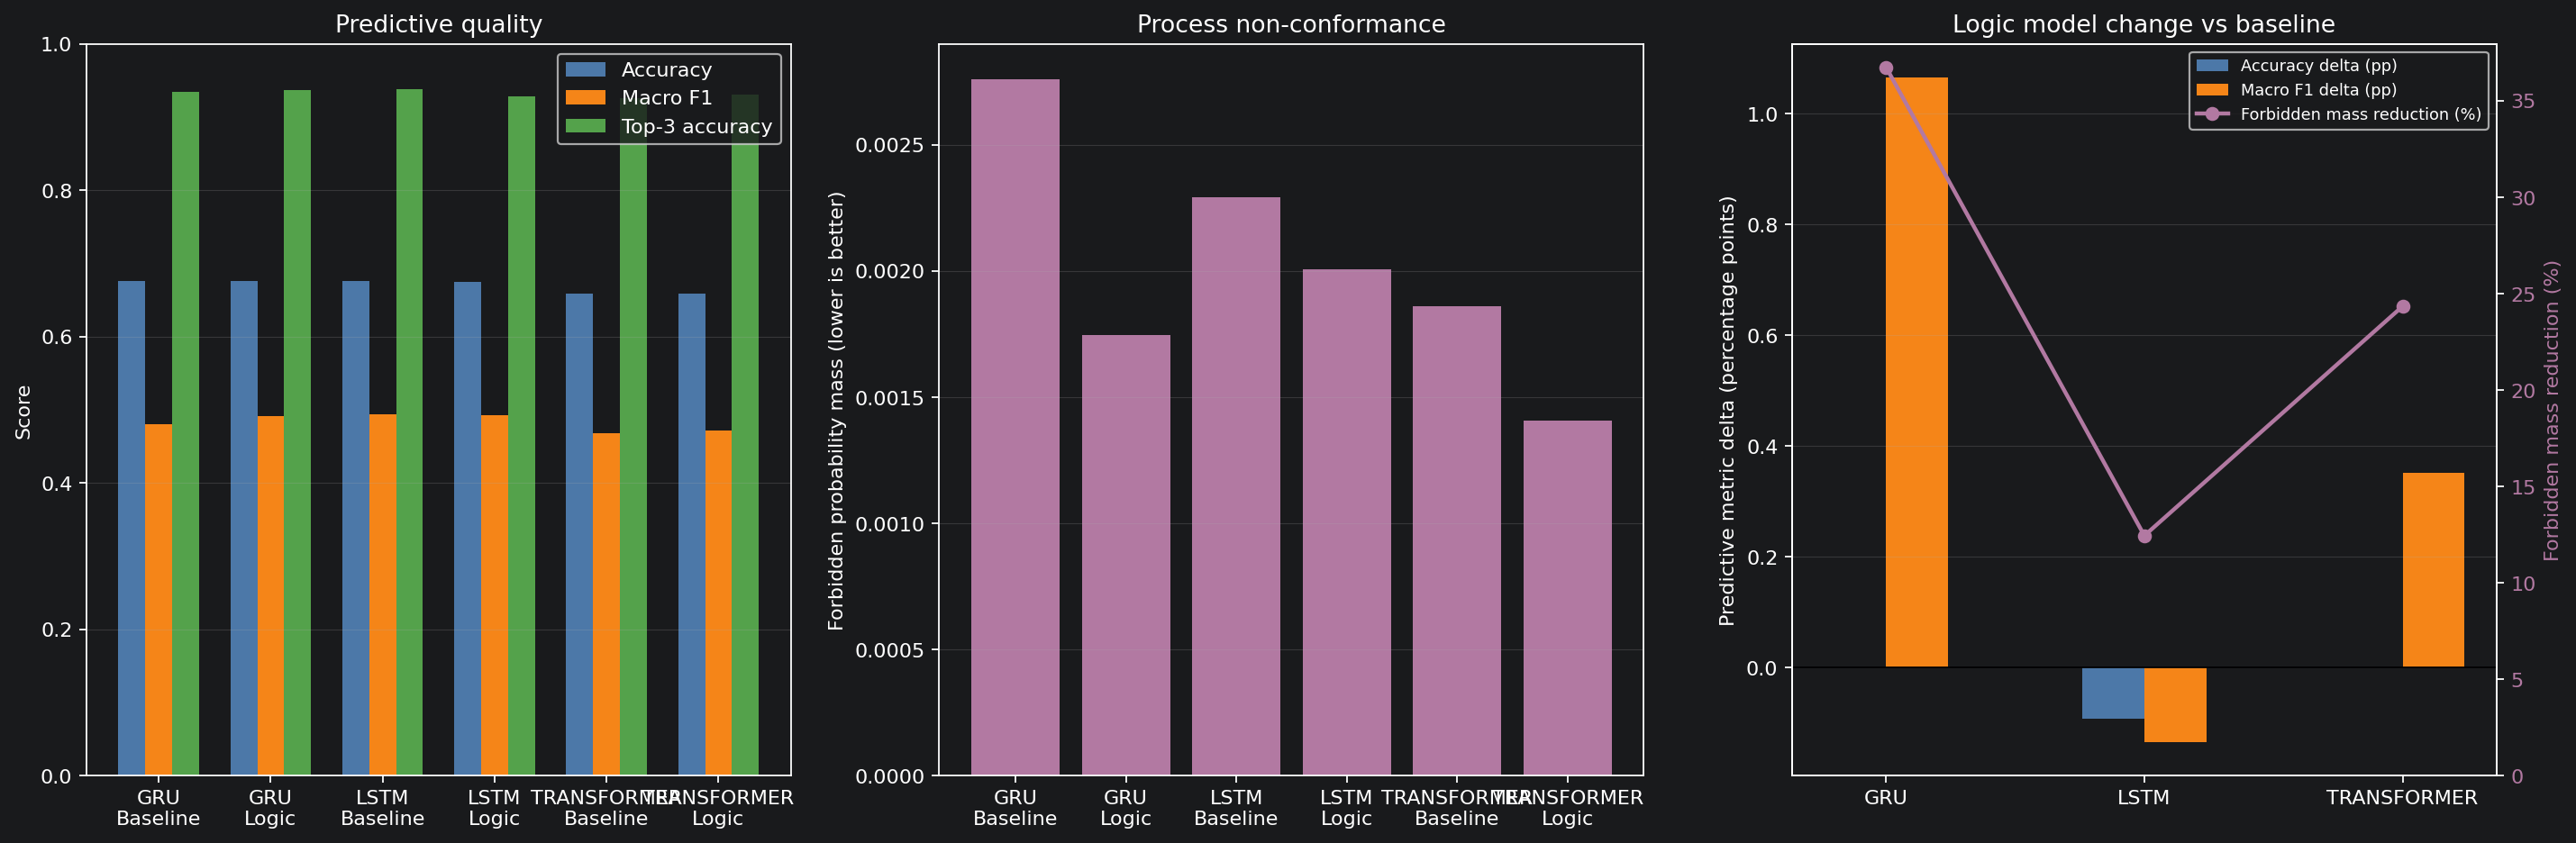

Il pannello sinistro confronta accuracy/F1/top-3; quello centrale isola la massa vietata; quello destro mostra il delta Logic - Baseline.


675

In [15]:
comparison_path = OUTPUT_DIR / "model_comparison.png"
plot_model_comparison(results, comparison_path)
display(Image(filename=comparison_path))

print(
    "Il pannello sinistro confronta accuracy/F1/top-3; "
    "quello centrale isola la massa vietata; "
    "quello destro mostra il delta Logic - Baseline."
)

results.to_csv(OUTPUT_DIR / "test_results.csv", index=False)
validation_search.to_csv(
    OUTPUT_DIR / "validation_logic_weight_search.csv", index=False
)
automaton.save(OUTPUT_DIR / "dfa.json")
(OUTPUT_DIR / "config.json").write_text(
    json.dumps(config.to_dict(), indent=2), encoding="utf-8"
)

## 12. Ramo embedder appreso (T-LEAF completo)

Le sezioni precedenti realizzano il ramo *checker-loss*: il DFA directly-follows
empirico viene convertito in una penalita diretta sulla probabilita delle
transizioni vietate. Qui aggiungiamo il contributo centrale di T-LEAF finora
assente, ossia la **logic loss su embedding appresi**:

1. estraiamo dalle tracce di training vincoli temporali LTLf di **precedenza**
   `(!b U a) | G(!b)` ("a precede b");
2. per ogni vincolo costruiamo un piccolo DFA con guardie proposizionali sugli
   archi;
3. un **embedder gerarchico** (`qe` sugli archi + `qm` sul grafo, con
   *edge to node lifting* e aggregazione random-walk dal nodo iniziale) proietta
   DFA e tracce in uno spazio vettoriale condiviso;
4. l'embedder e addestrato con una **triplet loss** (DFA vicino alle tracce che
   lo soddisfano, lontano da quelle che lo violano);
5. il modello target e addestrato con la logic loss
   `L = L_task + lambda * ||q(A) - q(w_pred)||^2`, dove l'ultimo passo predetto
   usa una feature "soft" (media pesata dalle probabilita) per restare
   differenziabile.

Semplificazioni dichiarate rispetto al paper: vincoli limitati al template di
precedenza; vincoli multipli combinati sommando le distanze per-DFA invece di
costruire l'automa prodotto; feature di attivita fisse casuali al posto di
GLoVe; embedder addestrato congiuntamente (`qe`+`qm`) invece che a stadi.

In [ ]:
import numpy as np

from src.Sepsis_Case.process.ltl_constraints import mine_precedence_constraints
from src.Sepsis_Case.process.graph_encoding import FeatureSpace
from src.Sepsis_Case.learning.embedder import HierarchicalEmbedder
from src.Sepsis_Case.learning.embedder_training import (
    EmbedderConfig,
    train_embedder,
    evaluate_embedder,
)
from src.Sepsis_Case.learning.logic import (
    EmbeddingLogicLoss,
    precedence_violation_rate,
)

# Vincoli di precedenza estratti SOLO dalle tracce di training.
MIN_SUPPORT = 5 if QUICK_RUN else 20
constraints = mine_precedence_constraints(
    splits.train.values(),
    min_support=MIN_SUPPORT,
    min_confidence=0.98,
    max_constraints=40,
)
print(f"Vincoli di precedenza estratti: {len(constraints)}")
constraint_table = pd.DataFrame(
    [
        {
            "earlier": c.earlier,
            "later": c.later,
            "support": c.support,
            "confidence": c.confidence,
            "ltlf": c.to_ltlf(),
        }
        for c in constraints
    ]
)
display(constraint_table.head(15).style.format({"confidence": "{:.3f}"}))

# Esempio di DFA per il primo vincolo (stati, tipi e guardie sugli archi).
example = constraints[0]
example_dfa = example.to_dfa()
print(f"\nDFA di esempio per: {example.earlier!r} precede {example.later!r}")
print("  stati (tipo):", {s: example_dfa.node_types[s] for s in example_dfa.states})
print("  accettanti  :", sorted(example_dfa.accepting))
for src, dst, guard in example_dfa.edges:
    if guard.is_true:
        label = "true"
    elif guard.positives:
        label = " & ".join(guard.positives)
    else:
        label = " & ".join(f"!{a}" for a in guard.negatives)
    print(f"  {src} -> {dst}  [{label}]")

feature_space = FeatureSpace.create(
    vocabulary.activities, prop_dim=50, node_dim=100, seed=config.seed, device=device
)

In [ ]:
# Addestramento dell'embedder gerarchico con la triplet loss (Eq. 7-8 del paper).
embedder = HierarchicalEmbedder(
    prop_dim=50,
    node_dim=100,
    out_dim=200,
    aggregation="random_walk",
    normalize=False,
    meta_layers=2,
).to(device)

embedder_config = EmbedderConfig(
    epochs=4 if QUICK_RUN else 12,
    triplets_per_constraint=12 if QUICK_RUN else 32,
    batch_size=16,
    trace_length=8,
    margin=5.0,
    learning_rate=2e-3,
    seed=config.seed,
)
embedder_history = train_embedder(
    embedder, feature_space, constraints, vocabulary.activities,
    embedder_config, device=device, verbose=True,
)
heldout_triplet_acc = evaluate_embedder(
    embedder, feature_space, constraints, vocabulary.activities,
    embedder_config, device=device,
)
print(f"\nAccuratezza tripletta su tracce held-out: {heldout_triplet_acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(embedder_history["epoch"], embedder_history["triplet_loss"], marker="o")
axes[0].set_title("Triplet loss"); axes[0].set_xlabel("epoch")
axes[1].plot(embedder_history["epoch"], embedder_history["triplet_accuracy"], marker="o")
axes[1].set_ylim(0, 1); axes[1].set_title("Triplet accuracy"); axes[1].set_xlabel("epoch")
fig.tight_layout()
embedder_curve_path = OUTPUT_DIR / "embedder_training.png"
fig.savefig(embedder_curve_path, dpi=120); plt.close(fig)
display(Image(filename=embedder_curve_path))

In [ ]:
# Modelli target con la logic loss su embedding. L'embedder e congelato e le
# sue ancore q(A) sono pre-calcolate una sola volta in EmbeddingLogicLoss.
# La loss e onerosa (embedding di un grafo per esempio), quindi per default
# usiamo GRU e LSTM; il Transformer puo essere aggiunto se serve.
EMBEDDER_ARCHITECTURES = ("gru", "lstm")
EMBEDDER_LOGIC_WEIGHT = 0.5

embedding_logic = EmbeddingLogicLoss(
    embedder, feature_space, constraints, vocabulary,
    max_examples=8 if QUICK_RUN else 16,
    max_constraints=3,
)

embedder_runs = {}
for architecture in EMBEDDER_ARCHITECTURES:
    run_config = replace(
        config, training=replace(config.training, logic_weight=EMBEDDER_LOGIC_WEIGHT)
    )
    weight_label = str(EMBEDDER_LOGIC_WEIGHT).replace(".", "p")
    run_name = f"{architecture}_embedder_w{weight_label}"
    print(f"\n--- {run_name} ---")
    training = train_model(
        model_kind=architecture,
        vocabulary=vocabulary,
        train_loader=loaders["train"],
        validation_loader=loaders["validation"],
        allowed_mask=allowed_mask,
        config=run_config,
        checkpoint_path=MODEL_DIR / f"{run_name}.pt",
        use_logic=True,
        logic_mode="embedder",
        embedding_logic=embedding_logic,
        epoch_callback=lambda row, name=run_name: print(
            f"{name} epoch={int(row['epoch']):02d} "
            f"train={row['train_loss']:.4f} val={row['validation_loss']:.4f}"
        ),
    )
    embedder_runs[run_name] = training
training_runs.update(embedder_runs)

In [ ]:
# Confronto a tre vie sul test set: baseline vs checker-loss vs embedder-loss.
# Aggiungiamo precedence_violation_rate, la metrica di conformita allineata alla
# conoscenza del ramo embedder (i vincoli di precedenza LTLf).
checker_label = str(LOGIC_WEIGHTS[0]).replace(".", "p")
embedder_label = str(EMBEDDER_LOGIC_WEIGHT).replace(".", "p")

three_way_rows = []
for architecture in EMBEDDER_ARCHITECTURES:
    variants = {
        "baseline": training_runs[f"{architecture}_baseline"],
        "checker": training_runs[f"{architecture}_logic_w{checker_label}"],
        "embedder": embedder_runs[f"{architecture}_embedder_w{embedder_label}"],
    }
    for mode, training in variants.items():
        ev = evaluate_model(
            training.model, loaders["test"], allowed_mask.to(device),
            device, top_k=config.training.top_k,
        )
        pvr = precedence_violation_rate(
            training.model, loaders["test"], constraints, vocabulary, device
        )
        three_way_rows.append(
            {
                "architecture": architecture,
                "logic_mode": mode,
                "accuracy": ev.accuracy,
                "macro_f1": ev.macro_f1,
                "top_k_accuracy": ev.top_k_accuracy,
                "forbidden_mass": ev.forbidden_mass,
                "violation_rate": ev.violation_rate,
                "precedence_violation_rate": pvr,
            }
        )

three_way = pd.DataFrame(three_way_rows)
display(three_way.style.format(precision=4))
three_way.to_csv(OUTPUT_DIR / "comparison_three_way.csv", index=False)

modes = ["baseline", "checker", "embedder"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (metric, title) in zip(
    axes,
    [("accuracy", "Accuracy (alto = meglio)"),
     ("precedence_violation_rate", "Violazioni di precedenza (basso = meglio)")],
):
    xs = np.arange(len(EMBEDDER_ARCHITECTURES))
    width = 0.25
    for j, mode in enumerate(modes):
        values = [
            three_way[(three_way.architecture == a) & (three_way.logic_mode == mode)][metric].iloc[0]
            for a in EMBEDDER_ARCHITECTURES
        ]
        ax.bar(xs + (j - 1) * width, values, width, label=mode)
    ax.set_xticks(xs); ax.set_xticklabels(EMBEDDER_ARCHITECTURES)
    ax.set_title(title); ax.legend()
fig.tight_layout()
three_way_path = OUTPUT_DIR / "three_way_comparison.png"
fig.savefig(three_way_path, dpi=120); plt.close(fig)
display(Image(filename=three_way_path))

### Lettura del confronto a tre vie

- Il ramo **checker** minimizza direttamente la `forbidden_mass` (la sua stessa
  funzione obiettivo, definita sull'automa directly-follows).
- Il ramo **embedder** ottimizza invece la distanza di embedding rispetto ai DFA
  dei vincoli di **precedenza**: il suo effetto va letto soprattutto sulla
  metrica `precedence_violation_rate`, allineata alla conoscenza che codifica.
- Le due perdite incorporano quindi tipi di conoscenza simbolica diversi ma
  complementari (next/directly-follows vs precedenza temporale); un calo di
  `precedence_violation_rate` a parita sostanziale di accuracy indica che la
  logic loss su embedding sta effettivamente guidando il modello verso predizioni
  temporalmente coerenti.
- L'accuratezza della tripletta dell'embedder e una metrica intermedia: un
  embedder addestrato piu a lungo (piu epoche/triplet) fornisce un gradiente piu
  informativo alla logic loss. Questo e ora il **ramo embedder-loss completo** di
  T-LEAF, non piu solo il ramo checker.

## 11. Criteri per le conclusioni

1. `logic_weight` e selezionato sulla validation, mai sul test.
2. Il candidato deve restare entro un punto percentuale dall'accuracy baseline.
3. Tra i candidati ammissibili scegliamo la minore `forbidden_mass`.
4. Il confronto finale sul test usa soltanto baseline e modello selezionato.
5. Una riduzione della massa vietata con accuracy stabile indica un miglioramento
   di conformita; un aumento di accuracy/F1 indica anche un miglioramento
   predittivo.
6. La Sezione 12 aggiunge il ramo embedder-loss completo di T-LEAF: vincoli
   LTLf di precedenza estratti dal log, embedder gerarchico (qe+qm) addestrato
   con triplet loss, e logic loss come distanza di embedding differenziabile.
   Il ramo checker resta disponibile come baseline simbolica di confronto.